# K-Mean++ Clustering Analysis

### 1.Import Library

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import urllib.request
import random

# Machine Learning Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


### 2.Load Graph Data 

In [2]:
df = pd.read_csv('bio-pathways-network.csv')

edges = list(zip(df['Gene ID 1'], df['Gene ID 2']))

G_human = nx.Graph()
G_human.add_edges_from(edges)

print("Human nodes:", len(G_human.nodes()), "edges:", len(G_human.edges()))

Human nodes: 21557 edges: 342353


In [3]:
import urllib.request

urllib.request.urlretrieve(
    'http://snap.stanford.edu/deepnetbio-ismb/ipynb/yeast.edgelist',
    'yeast.edgelist'
)
yeast_file = "yeast.edgelist"
G_yeast = nx.read_edgelist(yeast_file)
print("Yeast nodes:", len(G_yeast.nodes()), "edges:", len(G_yeast.edges()))

Yeast nodes: 6526 edges: 532180


Cluster sizes:
 final_cluster
0    4675
1    1040
2       4
3     190
4     617
Name: count, dtype: int64


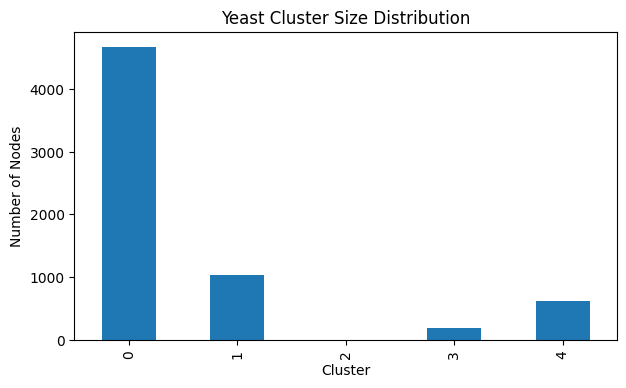

Cluster sizes:
 final_cluster
0      751
1    20806
Name: count, dtype: int64


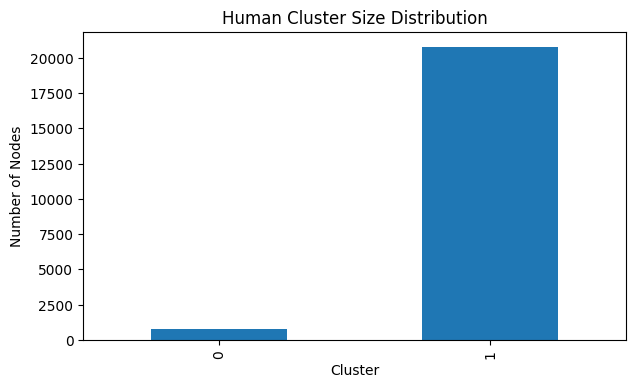

In [16]:
import matplotlib.pyplot as plt

def plot_cluster_size_distribution(features_df, cluster_col='final_cluster', title='Cluster Size Distribution'):
    cluster_sizes = features_df[cluster_col].value_counts().sort_index()
    print("Cluster sizes:\n", cluster_sizes)
    plt.figure(figsize=(7, 4))
    cluster_sizes.plot(kind='bar')
    plt.xlabel('Cluster')
    plt.ylabel('Number of Nodes')
    plt.title(title)
    plt.show()

# Example usage:
plot_cluster_size_distribution(features_yeast, cluster_col='final_cluster', title='Yeast Cluster Size Distribution')
plot_cluster_size_distribution(features_human, cluster_col='final_cluster', title='Human Cluster Size Distribution')


### 3.Compute Graph Features 

In [5]:
def compute_graph_features(G):
    # Degree of each node
    degree_dict = dict(G.degree())
    # Clustering coefficient
    clustering_dict = nx.clustering(G)
    # Betweenness centrality
    betweenness_dict = nx.betweenness_centrality(G)
    # Closeness centrality
    closeness_dict = nx.closeness_centrality(G)
    # Eigenvector centrality (works for connected graphs)
    eigenvector_dict = nx.eigenvector_centrality(G, max_iter=1000)

    # Collect features for each node
    features_df = pd.DataFrame({
        'degree': pd.Series(degree_dict),
        'clustering': pd.Series(clustering_dict),
        'betweenness': pd.Series(betweenness_dict),
        'closeness': pd.Series(closeness_dict),
        'eigenvector': pd.Series(eigenvector_dict)
    })

    return features_df

# Usage:
# features_yeast = compute_graph_features(G_yeast)
# features_human = compute_graph_features(G_human)

features_yeast = compute_graph_features(G_yeast)
print(features_yeast.head())  # Show the first 5 rows of features for yeast graph

features_human = compute_graph_features(G_human)
print(features_human.head())  # Show first 5 rows of features for human graph


         degree  clustering  betweenness  closeness  eigenvector
YLR418C     989    0.130588     0.001656   0.522962     0.048235
YOL145C     192    0.271122     0.000180   0.482976     0.012731
YOR123C     475    0.208613     0.000214   0.497408     0.028658
YBR279W     153    0.356026     0.000016   0.482119     0.011025
YML069W     697    0.151958     0.000703   0.507703     0.036273
        degree  clustering  betweenness  closeness  eigenvector
1394        12    0.045455     0.000208   0.308236     0.000439
2778        98    0.045833     0.000445   0.358432     0.003437
6331        33    0.036559     0.000067   0.332190     0.000962
17999       10    0.000000     0.000005   0.304976     0.000195
122704      93    0.753389     0.000023   0.342906     0.005960


### 4.K-Means++ Clustering Function

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def run_kmeans(features_df, n_clusters=3):
    # Scale features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_df)

    # Run KMeans with k-means++ initialization
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    cluster_labels = kmeans.fit_predict(features_scaled)

    # Add cluster labels to dataframe
    features_df['cluster'] = cluster_labels

    # Calculate silhouette score for clustering quality
    silhouette_avg = silhouette_score(features_scaled, cluster_labels)
    print(f'Silhouette score for {n_clusters} clusters: {silhouette_avg:.3f}')

    return features_df, kmeans

# Usage example for yeast features
features_yeast_clustered, kmeans_yeast = run_kmeans(features_yeast, n_clusters=3)
print(features_yeast_clustered.head())

# Usage example for human features
features_human_clustered, kmeans_human = run_kmeans(features_human, n_clusters=3)
print(features_human_clustered.head())


Silhouette score for 3 clusters: 0.485
         degree  clustering  betweenness  closeness  eigenvector  cluster
YLR418C     989    0.130588     0.001656   0.522962     0.048235        1
YOL145C     192    0.271122     0.000180   0.482976     0.012731        0
YOR123C     475    0.208613     0.000214   0.497408     0.028658        1
YBR279W     153    0.356026     0.000016   0.482119     0.011025        0
YML069W     697    0.151958     0.000703   0.507703     0.036273        1
Silhouette score for 3 clusters: 0.359
        degree  clustering  betweenness  closeness  eigenvector  cluster
1394        12    0.045455     0.000208   0.308236     0.000439        1
2778        98    0.045833     0.000445   0.358432     0.003437        0
6331        33    0.036559     0.000067   0.332190     0.000962        0
17999       10    0.000000     0.000005   0.304976     0.000195        1
122704      93    0.753389     0.000023   0.342906     0.005960        0


### 5.PCA Visualization of Graph Features 

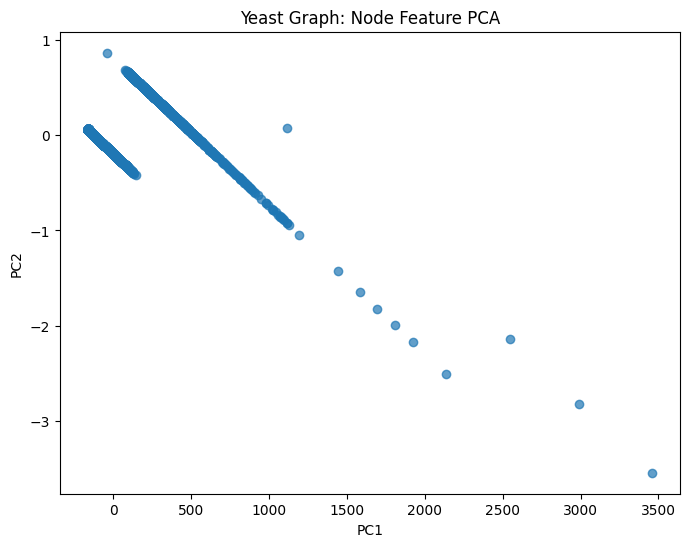

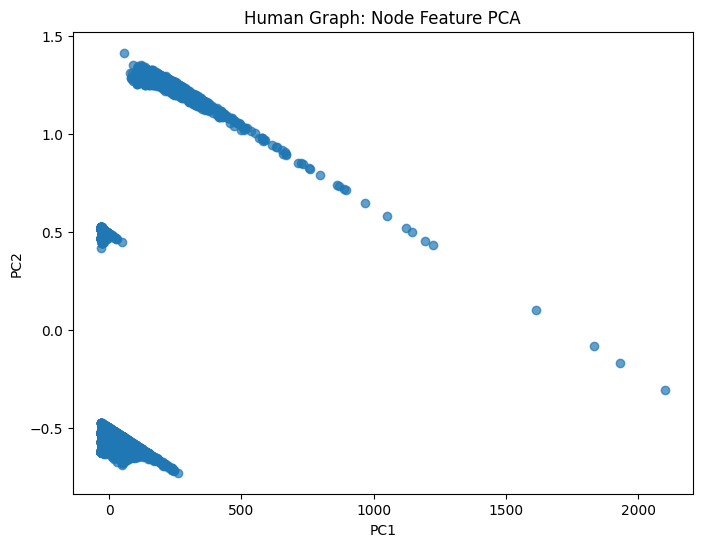

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_graph_features(features_df, title='Graph Features (PCA 2D)'):
    # Drop NaN/infinite, just in case
    features_numeric = features_df.select_dtypes(include=[float, int]).dropna()
    
    # PCA to 2 components
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(features_numeric)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.show()

# Visualize features for yeast and human graphs
plot_graph_features(features_yeast, 'Yeast Graph: Node Feature PCA')
plot_graph_features(features_human, 'Human Graph: Node Feature PCA')


In [8]:
# Summary stats for each cluster
print(features_yeast_clustered.groupby('cluster').mean())
print(features_human_clustered.groupby('cluster').mean())


              degree  clustering  betweenness  closeness  eigenvector
cluster                                                              
0          86.348736    0.205873     0.000039   0.449281     0.004655
1         474.652415    0.154671     0.000659   0.497085     0.023414
2        2691.500000    0.041777     0.042902   0.623093     0.076924
             degree  clustering  betweenness  closeness  eigenvector
cluster                                                             
0         40.008067    0.214642     0.000091   0.332098     0.002103
1          4.829483    0.024864     0.000006   0.282357     0.000154
2        307.704615    0.260055     0.001833   0.386112     0.032519


### 6.Cluster Visualisation with PCA 

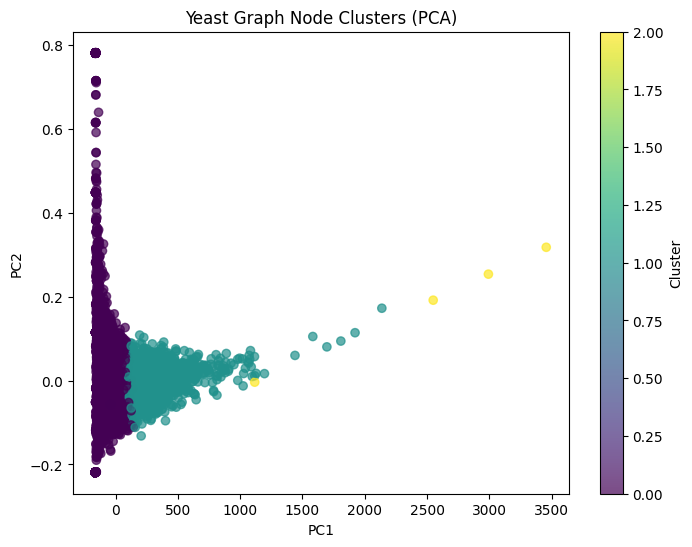

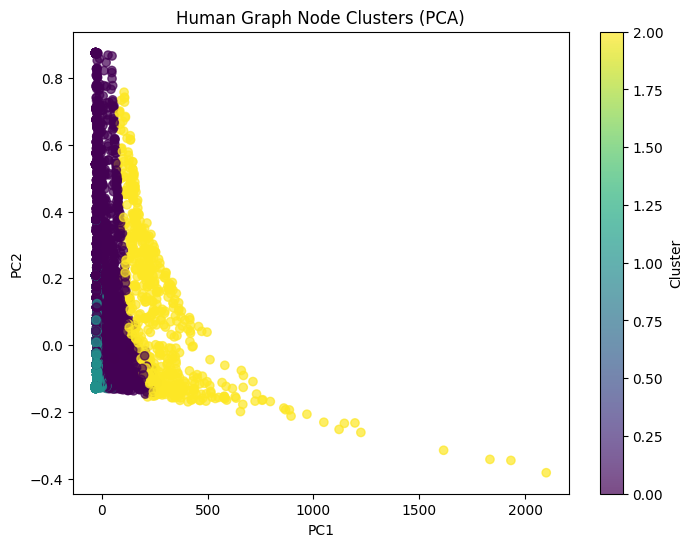

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_clusters(features_clustered, title='Cluster visualization'):
    X = features_clustered.drop('cluster', axis=1).values
    y = features_clustered['cluster'].values

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', alpha=0.7)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.colorbar(scatter, label='Cluster')
    plt.show()

plot_clusters(features_yeast_clustered, title='Yeast Graph Node Clusters (PCA)')
plot_clusters(features_human_clustered, title='Human Graph Node Clusters (PCA)')


### 7.Silhouette Evalution for optimal Clusters 

In [10]:
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    features_scaled = StandardScaler().fit_transform(features_yeast.drop('cluster', axis=1, errors='ignore'))
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(features_scaled)
    sil_score = silhouette_score(features_scaled, labels)
    print(f'Silhouette score for {n_clusters} clusters (yeast): {sil_score:.3f}')

    features_scaled_h = StandardScaler().fit_transform(features_human.drop('cluster', axis=1, errors='ignore'))
    kmeans_h = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    labels_h = kmeans_h.fit_predict(features_scaled_h)
    sil_score_h = silhouette_score(features_scaled_h, labels_h)
    print(f'Silhouette score for {n_clusters} clusters (human): {sil_score_h:.3f}')


Silhouette score for 2 clusters (yeast): 0.511
Silhouette score for 2 clusters (human): 0.748
Silhouette score for 3 clusters (yeast): 0.485
Silhouette score for 3 clusters (human): 0.359
Silhouette score for 4 clusters (yeast): 0.552
Silhouette score for 4 clusters (human): 0.423
Silhouette score for 5 clusters (yeast): 0.588
Silhouette score for 5 clusters (human): 0.425
Silhouette score for 6 clusters (yeast): 0.514
Silhouette score for 6 clusters (human): 0.428


### 8.Calinski Harabasz and Davies Bouldin Score 

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Yeast Features
scaler_yeast = StandardScaler()
features_yeast_scaled = scaler_yeast.fit_transform(features_yeast)  
calinski_score_yeast = calinski_harabasz_score(features_yeast_scaled, kmeans_yeast.labels_)
davies_score_yeast = davies_bouldin_score(features_yeast_scaled, kmeans_yeast.labels_)

print(f"Yeast Calinski-Harabasz Index: {calinski_score_yeast:.3f}")
print(f"Yeast Davies-Bouldin Index: {davies_score_yeast:.3f}")

# Human Features
scaler_human = StandardScaler()
features_human_scaled = scaler_human.fit_transform(features_human)
calinski_score_human = calinski_harabasz_score(features_human_scaled, kmeans_human.labels_)
davies_score_human = davies_bouldin_score(features_human_scaled, kmeans_human.labels_)

print(f"Human Calinski-Harabasz Index: {calinski_score_human:.3f}")
print(f"Human Davies-Bouldin Index: {davies_score_human:.3f}")


NameError: name 'features_yeast' is not defined

### 8. Final CLustering 

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Example: use n_clusters=2 for yeast, n_clusters=2 for human (based on your scores)
# Change these if you select a different value

optimal_n_yeast = 5
optimal_n_human = 2

# Scale yeast features (exclude any pre-existing cluster labels if present)
features_yeast_scaled = StandardScaler().fit_transform(features_yeast.drop('cluster', axis=1, errors='ignore'))

# Fit KMeans and assign final labels for yeast
kmeans_yeast_final = KMeans(n_clusters=optimal_n_yeast, init='k-means++', random_state=42)
yeast_final_labels = kmeans_yeast_final.fit_predict(features_yeast_scaled)
features_yeast['final_cluster'] = yeast_final_labels

# Scale human features
features_human_scaled = StandardScaler().fit_transform(features_human.drop('cluster', axis=1, errors='ignore'))

# Fit KMeans and assign final labels for human
kmeans_human_final = KMeans(n_clusters=optimal_n_human, init='k-means++', random_state=42)
human_final_labels = kmeans_human_final.fit_predict(features_human_scaled)
features_human['final_cluster'] = human_final_labels

# Print cluster assignment head
print(features_yeast.head())
print(features_human.head())


         degree  clustering  betweenness  closeness  eigenvector  cluster  \
YLR418C     989    0.130588     0.001656   0.522962     0.048235        1   
YOL145C     192    0.271122     0.000180   0.482976     0.012731        0   
YOR123C     475    0.208613     0.000214   0.497408     0.028658        1   
YBR279W     153    0.356026     0.000016   0.482119     0.011025        0   
YML069W     697    0.151958     0.000703   0.507703     0.036273        1   

         final_cluster  
YLR418C              1  
YOL145C              0  
YOR123C              1  
YBR279W              0  
YML069W              1  
        degree  clustering  betweenness  closeness  eigenvector  cluster  \
1394        12    0.045455     0.000208   0.308236     0.000439        1   
2778        98    0.045833     0.000445   0.358432     0.003437        0   
6331        33    0.036559     0.000067   0.332190     0.000962        0   
17999       10    0.000000     0.000005   0.304976     0.000195        1   
122704 

In [12]:
print(features_yeast.groupby('final_cluster').mean())
print(features_yeast.groupby('final_cluster').std())

print(features_human.groupby('final_cluster').mean())
print(features_human.groupby('final_cluster').std())


                    degree  clustering   betweenness  closeness  eigenvector  \
final_cluster                                                                  
0               110.039572    0.199015  5.327562e-05   0.468675     0.005907   
1               515.363462    0.151552  7.557453e-04   0.499207     0.025277   
2              2691.500000    0.041777  4.290218e-02   0.623093     0.076924   
3                 4.794737    0.857319  1.149412e-07   0.367490     0.000327   
4                 3.679092    0.043980  4.717212e-06   0.341221     0.000144   

                cluster  
final_cluster            
0              0.047701  
1              1.000000  
2              2.000000  
3              0.000000  
4              0.000000  
                    degree  clustering   betweenness  closeness  eigenvector  \
final_cluster                                                                  
0                74.049769    0.074435  1.849512e-04   0.016112     0.003811   
1               2

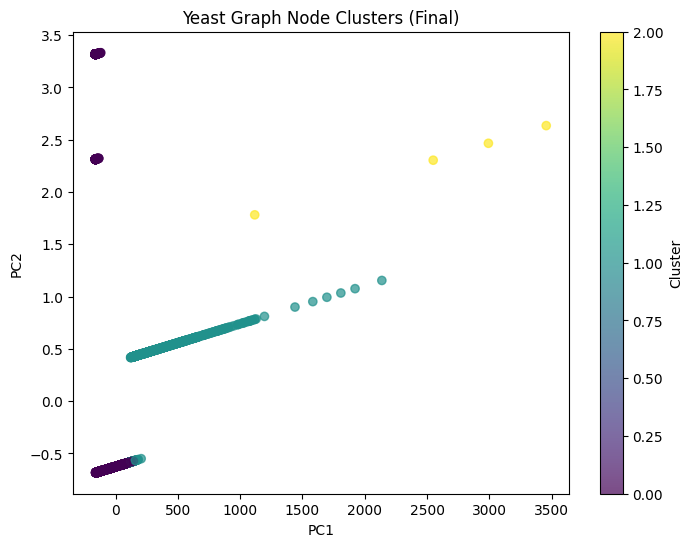

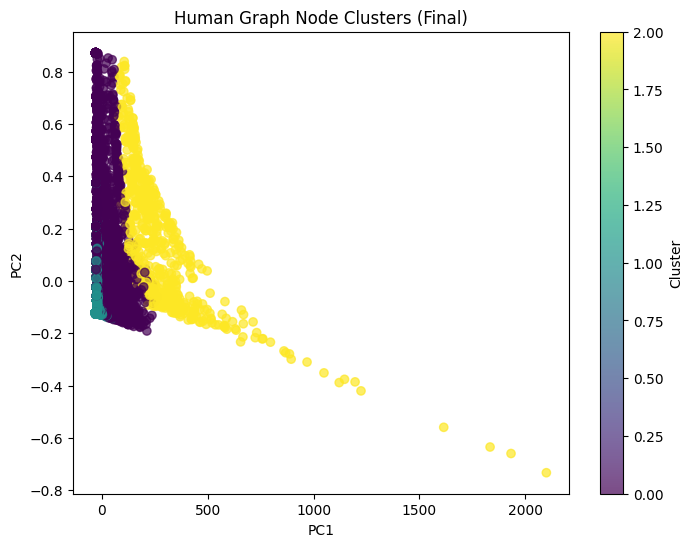

In [13]:
plot_clusters(features_yeast, title='Yeast Graph Node Clusters (Final)')
plot_clusters(features_human, title='Human Graph Node Clusters (Final)')


### 9.Graph Visualisation 

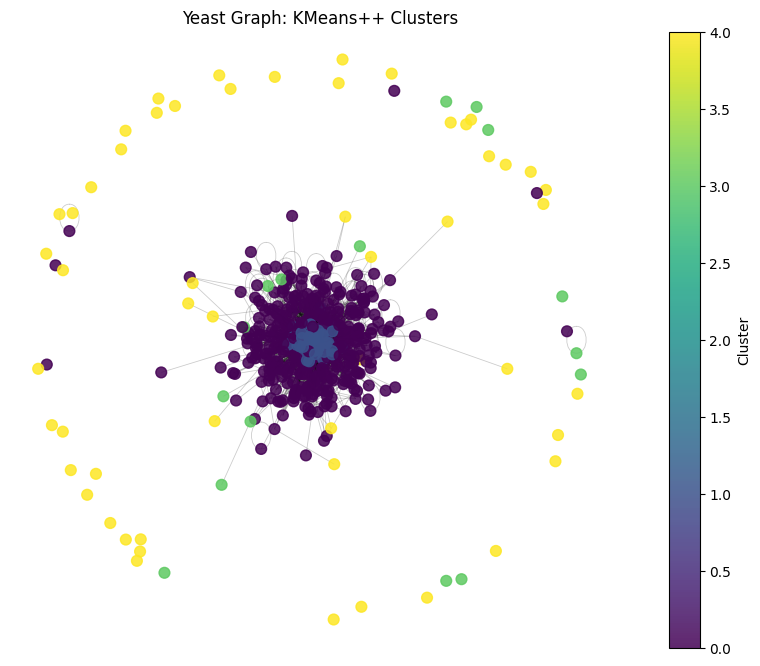

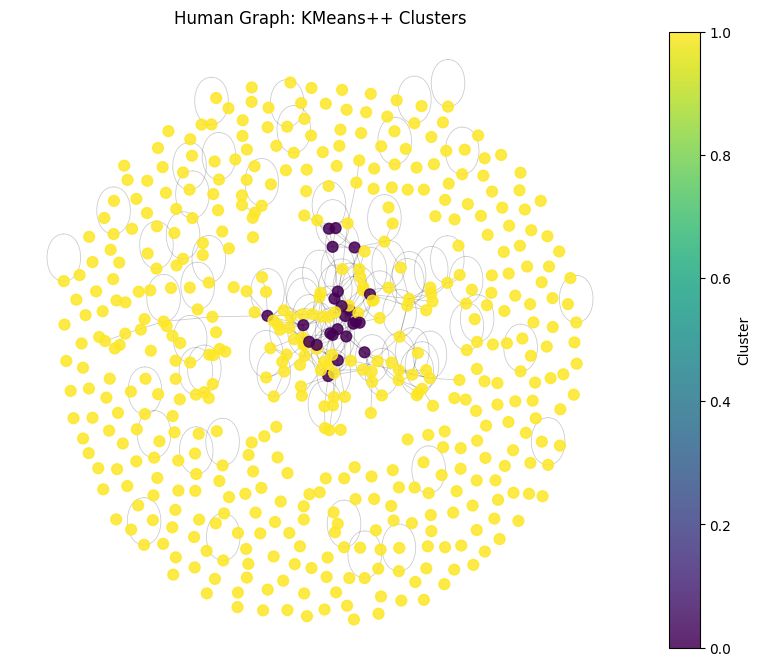

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def draw_graph_with_clusters(G, features_df, cluster_col='final_cluster', title='Graph with Cluster Coloring', node_size=60, max_nodes=500):
    # Limit graph size for visualization
    if len(G.nodes) > max_nodes:
        # sample a subgraph with max_nodes nodes
        nodes_subset = random.sample(list(G.nodes()), max_nodes)
        G = G.subgraph(nodes_subset)
        features_df = features_df.loc[nodes_subset]

    clusters = features_df[cluster_col]
    node_color_list = [clusters.loc[node] if node in clusters.index else 0 for node in G.nodes()]

    plt.figure(figsize=(10, 8))
    # Use a scalable layout; spring_layout is OK for small sampled graphs
    pos = nx.spring_layout(G, seed=42, k=0.1, iterations=20)
    nodes = nx.draw_networkx_nodes(G, pos, node_color=node_color_list, cmap='viridis', node_size=node_size, alpha=0.85)
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.6)
    plt.title(title)
    plt.colorbar(nodes, label='Cluster')
    plt.axis('off')
    plt.show()

    # Usage:
draw_graph_with_clusters(G_yeast, features_yeast, cluster_col='final_cluster', title='Yeast Graph: KMeans++ Clusters')
draw_graph_with_clusters(G_human, features_human, cluster_col='final_cluster', title='Human Graph: KMeans++ Clusters')
